# Class 11: Statcast data, simulating observed performance statistics, and Bayesian inference

The class code for today very briefly discusses three topics: exploring statcast data, simulating observed performance statistics from underlying abilities, and Bayesian inference. This brief code should help a little with lab 9 and could give some ideas for your project. The code is not meant to be comprehensive, but it should give you a starting point for exploring these topics on your own. 


In [12]:
import YData_baseball

#YData_baseball.download_data("verlander_stats_2017.csv")


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part 1: Exploring Verlander's spin rate using statcast data

As discussed in Astroball, Justin Verlander claimed that he figured out a way to increase the spin rate on his slider on June 21st, 2017. Let's explore this claim using the statcast data. We will use the `pybaseball` package to access the statcast data for Justin Verlander in the 2017 season and then we will visualize his slider spin rate over the course of the season to see if there is a noticeable increase after June 21st. 


In [14]:
from pybaseball import playerid_lookup, statcast_pitcher

# look up Justin Verlander's Statcast player ID
print(playerid_lookup('verlander'))


   name_last name_first  key_mlbam key_retro  key_bbref  key_fangraphs  \
0  verlander     justin     434378  verlj001  verlaju01           8700   

   mlb_played_first  mlb_played_last  
0            2005.0           2025.0  


In [15]:
# If the code above is too slow or doesn't work you can load the data using this code
#verlander_stats = pd.read_csv("verlander_stats_2017.csv")


# get Justin Verlander's Statcast data for the 2017 season
verlander_stats = statcast_pitcher('2017-01-01', '2017-12-31', 434378)


verlander_stats.head()


Gathering Player Data


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2017-10-31,97.4,-1.94,6.72,"Verlander, Justin",641355,434378,strikeout,swinging_strike,...,1.0,0.50,0.85,-0.85,NaN,NaN,NaN,NaN,NaN,NaN
1,FF,2017-10-31,97.1,-1.86,6.77,"Verlander, Justin",641355,434378,NaN,foul,...,1.0,0.61,0.92,-0.92,NaN,NaN,NaN,NaN,NaN,NaN
2,FF,2017-10-31,96.1,-1.86,6.86,"Verlander, Justin",641355,434378,NaN,swinging_strike,...,1.0,0.48,0.74,-0.74,NaN,NaN,NaN,NaN,NaN,NaN
3,FF,2017-10-31,96.6,-1.84,6.85,"Verlander, Justin",641355,434378,NaN,ball,...,1.0,0.43,0.92,-0.92,NaN,NaN,NaN,NaN,NaN,NaN
4,FC,2017-10-31,91.5,-2.21,6.59,"Verlander, Justin",457759,434378,field_out,hit_into_play,...,1.0,1.59,-0.10,-0.10,NaN,NaN,NaN,NaN,NaN,NaN


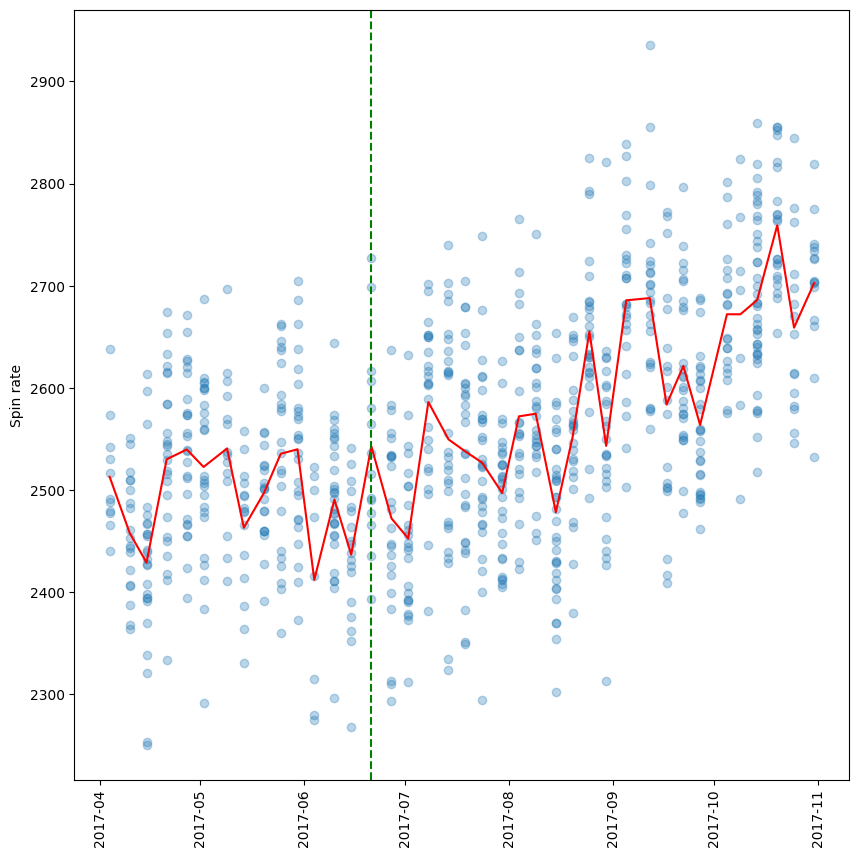

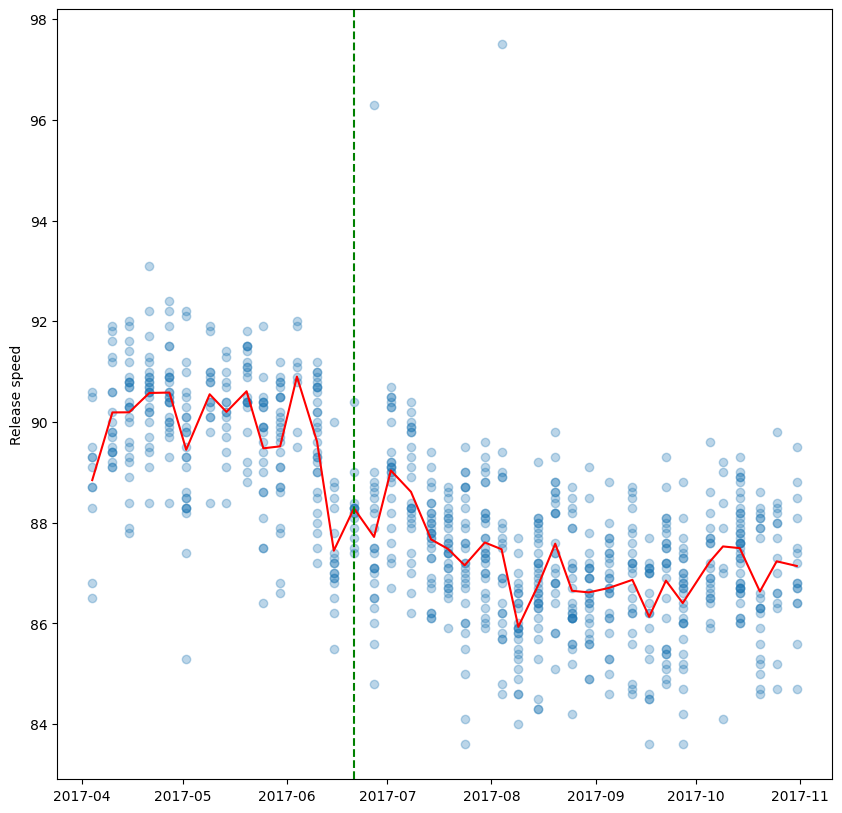

In [16]:

# Getting the slider data and removing a few outliers to make the plot easier to read. 
# We will also convert the game date to a datetime object so that we can plot it on the x-axis. 

verlander_slider = verlander_stats.query("pitch_type == 'SL'")
verlander_slider = verlander_slider.query("release_spin_rate > 2250")   # remove a few outliers
verlander_slider["game_date"] = pd.to_datetime(verlander_slider["game_date"])


plt.figure()
plt.rcParams['figure.figsize'] = [10, 10]

# the spin rate of all sliders as a function of the date
plt.scatter(verlander_slider['game_date'], verlander_slider['release_spin_rate'], alpha = .3);
plt.xticks(rotation = 90);

# plot a line for the average spin rate for each date
ave_spin_rate = verlander_slider.groupby('game_date')['release_spin_rate'].mean().reset_index()
plt.plot(ave_spin_rate['game_date'], ave_spin_rate['release_spin_rate'], color = "r");
plt.ylabel("Spin rate");

# add a vertical line on June 21st
plt.axvline(pd.to_datetime('2017-06-21'), color = 'g', linestyle = '--');


# Let's also plot his release speed
plt.figure()
plt.scatter(verlander_slider['game_date'], verlander_slider['release_speed'], alpha = .3);
ave_speed = verlander_slider.groupby('game_date')['release_speed'].mean().reset_index()
plt.plot(ave_spin_rate['game_date'], ave_speed ['release_speed'], color = "r");
plt.ylabel("Release speed");
plt.axvline(pd.to_datetime('2017-06-21'), color = 'g', linestyle = '--');


# Part 2: Generating observed performance statistics from underlying abilities

As we've seen before, we can generate an observed performance statistic (like batting average) from an underlying ability (like true batting ability) by simulating data. For example, if we assume that a player's true batting ability is 0.300, we can simulate their observed batting average over 611 at-bats by using a binomial distribution. The number of successes in the binomial distribution would be the number of hits, and the number of trials would be the number of at-bats. We can then divide the number of hits by the number of at-bats to get the simulated observed batting average performance. 



In [17]:

# Simulate the observed batting average for a player with a true batting ability of 0.300 over 611 at-bats

np.random.binomial(611, .300)/611 



0.3044189852700491

The function below simulates the observed batting average for a list of players with different true batting abilities over a specified number of at-bats. The function takes in a list of true batting abilities and the number of at-bats, and it returns a list of observed batting averages for each player. 

Please look over this function and make sure it makes sense. You will use this function on lab 9 to simulate the observed batting averages for a list of players with different true batting abilities. 

In [18]:
def simulate_players_stats(batting_abilities, n):
    
    all_stats = []
    
    for i in np.arange(0, len(batting_abilities)):
        
        prob_heads = batting_abilities[i]
        
        curr_stat = np.random.binomial(n, prob_heads)/n 
        
        all_stats.append(curr_stat)
        
    return all_stats



# simulate the observed batting averages for 3 players with true batting abilities of 0.300, 0.400, and 0.500 over 600 at-bats

simulate_players_stats([.3, .4, .5], 600)


[0.30833333333333335, 0.38333333333333336, 0.49333333333333335]

## Part 2:  Bayesian inference

Bayesian inference is a method of statistical inference in which Bayes' theorem is used to update the probability for a hypothesis as more evidence or information becomes available. It is based on the idea that we can use prior knowledge or beliefs about a parameter (the prior distribution) and update that knowledge with new data (the likelihood) to get a new distribution (the posterior distribution) that reflects our updated beliefs about the parameter. 

Bayes' theorem can be written as: $$P(\theta | D) = \frac{P(D | \theta) P(\theta)}{P(D)}$$

where:
- $P(\theta | D)$ is the posterior probability of the parameter $\theta$ given the data $D$
- $P(D | \theta)$ is the likelihood of the data given the parameter $\theta$
- $P(\theta)$ is the prior probability of the parameter $\theta$

We can also state this as:  Posterior = (Likelihood * Prior) / P(data)


## Example

Suppose there were 3 possible true batting abilities for a player: 0.200, 0.333, and 0.500, and we have no reason to believe that any of these abilities are more likely than the others (so we assign them equal prior probabilities of 1/3). 

If we then observe that the player has a batting average of 0.200 (2 hits) over 10 at-bats, we can use Bayes' theorem to update our beliefs about the player's true batting ability based on this new data. We would calculate the likelihood of observing a batting average of 0.200 for each of the possible true batting abilities and then use those likelihoods along with the prior probabilities to calculate the posterior probabilities for each true batting ability. 


In [ ]:
import scipy.stats as stats

possible_parameters = np.array([1/5, 1/3, 1/2])
prior_probabilities = np.array([1/3, 1/3, 1/3])

n = 10
k = 2

likelihoods = stats.binom.pmf(k, n, possible_parameters)

posterior_probabilities = likelihoods * prior_probabilities / sum(likelihoods * prior_probabilities)

posterior_probabilities


In [1]:
%%capture

# Note: Jupyter notebooks with interactive graphics do not render well as pdfs
!quarto render class_11_answers.ipynb --cache-refresh --to pdf 
